# A/B Testing NLP Preprocessing for IndoBERT

Notebook ini bertujuan untuk membandingkan dua metode preprocessing NLP menggunakan pendekatan A/B Testing dan uji statistik Paired T-Test.

- Method A : Basic Preprocessing
- Method B : Enhanced Preprocessing

Eksperimen dilakukan untuk mengetahui apakah preprocessing lanjutan memberikan perbedaan signifikan terhadap hasil preprocessing teks.

#Install Library

In [ ]:
!pip install swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16505 sha256=6c49b9469ac8c7094fa71d2be71739501101052e7e900433f22985d32a58401c
  Stored in directory: /root/.cache/pip/wheels/d9/31/ff/ff51141a088571a9f672449e5aad5ea8bb35ca5d95ba135f30
Successfully built swifter


#Import Library

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import swifter
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

#Load Dataset

In [ ]:
df_epo = pd.read_csv('https://raw.githubusercontent.com/raihanmeintaro/Dataset/refs/heads/main/NLP/V2/df_epo_raw.csv')
df_llm = pd.read_csv('https://raw.githubusercontent.com/raihanmeintaro/Dataset/refs/heads/main/NLP/V2/df_llm_raw.csv')


#Synthetic Logic

Class Distribution

In [ ]:
class_counts = df_epo['emotion_label'].value_counts()

print(class_counts)

emotion_label
neutral    2001
happy      1275
angry      1130
sad        1003
anxious     911
Name: count, dtype: int64


Total Sythetic

In [ ]:
total_synthetic = int(len(df_epo) * 0.30)

print(f"Total synthetic: {total_synthetic}")

Total synthetic: 1896


Calculate Deficit

In [ ]:
max_count = class_counts.max()
deficits = {}
total_deficit = 0

for label, count in class_counts.items():
    deficit = max_count - count
    deficits[label] = deficit
    total_deficit += deficit

print(deficits)

{'neutral': 0, 'happy': 726, 'angry': 871, 'sad': 998, 'anxious': 1090}


##Synthetic Allocation

In [ ]:
synthetic_allocation = {}

for label, deficit in deficits.items():
    allocation = int((deficit / total_deficit) * total_synthetic)
    synthetic_allocation[label] = allocation

print(synthetic_allocation)

{'neutral': 0, 'happy': 373, 'angry': 448, 'sad': 513, 'anxious': 560}


Generate Balanced Dataset

In [ ]:
final_data = []

for label in class_counts.index:

    real_subset = df_epo[df_epo['emotion_label'] == label]
    final_data.append(real_subset)

    # SYNTHETIC DATA
    synth_count = synthetic_allocation[label]

    if synth_count > 0:
        synthetic_subset = df_llm[df_llm['emotion_label'] == label].sample(n=synth_count, replace=True, random_state=42)
        final_data.append(synthetic_subset)

# FINAL DATAFRAME
df_final = pd.concat(final_data, ignore_index=True)

df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_final.shape)
print(df_final['emotion_label'].value_counts())

(8214, 4)
emotion_label
neutral    2001
happy      1648
angry      1578
sad        1516
anxious    1471
Name: count, dtype: int64


In [ ]:
df = df_final.copy()

##Shuffling Dataset

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

##Missing Values Handling

In [ ]:
df = df.dropna(subset=['text', 'emotion_label', 'stress_label'])
df = df.reset_index(drop=True)

print(df.isnull().sum())

Unnamed: 0       0
text             0
emotion_label    0
stress_label     0
dtype: int64


#Load Dictionary

##Load Kamus Alay from GitHub

In [ ]:
alay_df = pd.read_csv('https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv')

# Buat Dictionary
alay_dict = dict(zip(alay_df['slang'], alay_df['formal']))

print("Kamus alay:", len(alay_dict))

Kamus alay: 4331


##Load Additional Kamus Alay

In [ ]:
new_alay_df = pd.read_csv('https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/new_kamusalay.csv', encoding='latin-1', names=['slang', 'formal'])

# Buat Dictionary
new_alay_dict = dict(zip(new_alay_df['slang'], new_alay_df['formal']))

print("Typo dictionary:", len(new_alay_dict))

Typo dictionary: 15167


##Merge Kamus Alay Dictionary

In [ ]:
combined_dict = {}

combined_dict.update(alay_dict)

combined_dict.update(new_alay_dict)

print("Total combined dictionary:", len(combined_dict))

Total combined dictionary: 15625


##Mapping Emoji Dictionary

In [ ]:
emoji_dict = {

    "😭": " sedih ",
    "😢": " sedih ",
    "😔": " sedih ",

    "😡": " marah ",
    "😠": " marah ",

    "😊": " senang ",
    "😁": " senang ",
    "😄": " senang ",

    "😨": " takut ",
    "😰": " cemas ",
    "😥": " cemas "
}

#Pre-Processing

##Casefolding (lower text)

In [ ]:
def case_folding(text):

    return text.lower()

##Cleaning Text

In [ ]:
def clean_text(text):

    # remove placeholder
    text = re.sub(r'\[.*?\]', ' ', text)

    # remove url
    text = re.sub(r"http\S+", " ", text)

    text = re.sub(r"www\S+", " ", text)

    # remove html
    text = re.sub(r"<.*?>", " ", text)

    # remove mention
    text = re.sub(r"@\w+", " ", text)

    # remove hashtag
    text = re.sub(r"#\w+", " ", text)

    # remove number
    text = re.sub(r"\d+", " ", text)

    # normalize laugh
    text = re.sub(r'(wkwk+|haha+|hehe+)',' lucu ', text)

    # normalize repeated char
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # remove punctuation
    text = re.sub(
        r'[%s]' % re.escape(string.punctuation), ' ', text)

    # remove non alphabet
    text = re.sub(r'[^a-zA-Z\s]',' ', text)

    # remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

##Additonal Dictionary

In [ ]:
custom_normalization = {

    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "tdk": "tidak",

    "bgt": "banget",
    "bgtt": "banget",

    "capek": "lelah",
    "cape": "lelah",

    "ngeri": "takut",

    "ovt": "cemas",
    "overthinking": "cemas",

    "stress": "cemas",

    "gw": "saya",
    "gue": "saya",

    "lu": "kamu",
    "loe": "kamu",

    "yg": "yang",
    "dr": "dari",

    "krn": "karena",
    "karna": "karena",

    "trs": "terus",

    "udh": "sudah",
    "udah": "sudah",

    "jg": "juga",

    "org": "orang"
}

##Typo Normalization

In [ ]:
def normalize_typo(text):
    words = text.split()
    normalized_words = []

    for word in words:
        normalized_words.append(
            custom_normalization.get(
                word,
                word
            )
        )

    return " ".join(normalized_words)

##Convert Emoji

In [ ]:
def convert_emoji(text):
    for emo, meaning in emoji_dict.items():
        text = text.replace(emo, meaning)
    return text

##Repeat Text

In [ ]:
def normalize_repeat(text):
    text = re.sub(
        r'(.)\1{2,}',
        r'\1\1',
        text
    )

    return text

##Text Normalization

In [ ]:
def normalize_text(text):
    words = text.split()
    normalized_words = []

    for word in words:
        normalized_words.append(
            combined_dict.get(
                word,
                word
            )
        )

    return " ".join(normalized_words)

#Method A (Basic Preprocessing)

In [ ]:
def preprocess_a(text):

    text = str(text)
    text = case_folding(text)
    text = clean_text(text)

    return text

Method A menggunakan preprocessing dasar:
- case folding
- clean text

Method ini digunakan sebagai baseline preprocessing.

#Method B (Enhanced Preprocessing)

In [ ]:
def preprocess_b(text):
    text = str(text)
    text = case_folding(text)
    text = normalize_typo(text)
    text = convert_emoji(text)
    text = clean_text(text)
    text = normalize_repeat(text)
    text = normalize_text(text)

    return text

Method B menggunakan preprocessing lanjutan:
- typo normalization
- emoji conversion
- repeated character normalization
- text normalization

Method ini diharapkan menghasilkan teks yang lebih bersih dan konsisten.

#Apply A/B Testing

In [ ]:
df['method_a'] = df['text'].swifter.apply(preprocess_a)
df['method_b'] = df['text'].swifter.apply(preprocess_b)

df[['text', 'method_a', 'method_b']].head(10)

Pandas Apply:   0%|          | 0/8214 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/8214 [00:00<?, ?it/s]

,text,method_a,method_b
0,kehilangan semangat buat ngapa ngapain padahal...,kehilangan semangat buat ngapa ngapain padahal...,kehilangan semangat buat kenapa apa padahal su...
1,tapi mnrtku ga aneh nder normal aja,tapi mnrtku ga aneh nder normal aja,tapi menurutku tidak aneh nder normal saja
2,ruhut kader terbaik dlm hal menjilat..bego di ...,ruhut kader terbaik dlm hal menjilat bego di p...,ruhut kader terbaik dalam hal menjilat bego di...
3,kamu yang tolol + kayak tytyd. ngejawab tapi g...,kamu yang tolol kayak tytyd ngejawab tapi ga r...,kamu yang tolol kayak titit ngejawab tapi tida...
4,sebenernya udah ga cenggeng ko ndii.. cuma aku...,sebenernya udah ga cenggeng ko ndii cuma aku s...,sebenarnya sudah tidak cenggeng kok ndii cuma ...
5,eh anjing emg baim mana baim tu rada tau ga lo...,eh anjing emg baim mana baim tu rada tau ga lo...,eh anjing memang baim mana baim itu agak tau t...
6,takut tergoda membeli pc lain,takut tergoda membeli pc lain,takut tergoda membeli pc lain
7,hari ini produktif dan mood bagus jujur aja di...,hari ini produktif dan mood bagus jujur aja di...,hari ini produktif dan suasana hati bagus juju...
8,rasanya kosong aja hari ini banget di kampus s...,rasanya kosong aja hari ini banget di kampus s...,rasanya kosong saja hari ini banget di kampus ...
9,kesel banget sama orang yang ga tepat waktu ba...,kesel banget sama orang yang ga tepat waktu ba...,kesal banget sama orang yang tidak tepat waktu...


Preprocessing diterapkan pada seluruh dataset menggunakan kedua metode.

Hasil preprocessing ditampilkan untuk membandingkan perubahan teks.

#Token Count Comparison

In [ ]:
df['token_a'] = df['method_a'].apply(lambda x: len(x.split()))
df['token_b'] = df['method_b'].apply(lambda x: len(x.split()))

df[['token_a', 'token_b']].head()

,token_a,token_b
0,11,11
1,7,7
2,13,13
3,41,42
4,41,41


Jumlah token dihitung untuk setiap metode preprocessing.

Token count digunakan sebagai metrik numerik dalam pengujian statistik.

#Vocabulary Size

In [ ]:
vocab_a = set(" ".join(df['method_a']).split())
vocab_b = set(" ".join(df['method_b']).split())

print("Vocabulary Method A :", len(vocab_a))
print("Vocabulary Method B :", len(vocab_b))

Vocabulary Method A : 15376
Vocabulary Method B : 13413


Vocabulary size digunakan untuk melihat jumlah kata unik yang dihasilkan oleh masing-masing metode preprocessing.

#Visualisasi Vocabulary

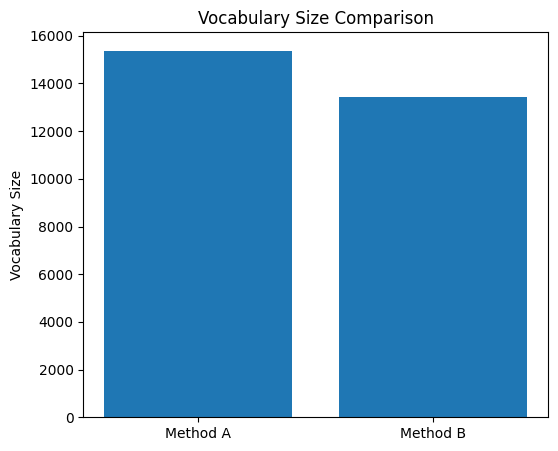

In [ ]:
methods = ['Method A', 'Method B']
vocab_sizes = [len(vocab_a), len(vocab_b)]

plt.figure(figsize=(6,5))

plt.bar(methods, vocab_sizes)

plt.title("Vocabulary Size Comparison")
plt.ylabel("Vocabulary Size")

plt.show()

#Hipotesis A/B Testing

H0 (Null Hypothesis):
Tidak terdapat perbedaan signifikan antara Method A dan Method B.

H1 (Alternative Hypothesis):
Terdapat perbedaan signifikan antara Method A dan Method B.

Alpha:
0.05

#Paired T-Test

In [ ]:
statistic, p_value = ttest_rel(df['token_a'], df['token_b'])

print("T-Statistic :", statistic)
print("P-Value :", p_value)

T-Statistic : -34.222093616904715
P-Value : 4.5476314668505244e-240


Paired T-Test digunakan untuk menguji apakah terdapat perbedaan signifikan antara jumlah token Method A dan Method B.

Karena kedua metode diuji pada dataset yang sama, maka digunakan paired test.

#Keputusan Statistik

In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Terdapat perbedaan signifikan antara Method A dan Method B")
else:
    print("Fail to Reject H0")
    print("Tidak terdapat perbedaan signifikan antara Method A dan Method B")

Reject H0
Terdapat perbedaan signifikan antara Method A dan Method B


Keputusan statistik ditentukan berdasarkan nilai p-value.

- Jika p-value < 0.05 → H0 ditolak
- Jika p-value >= 0.05 → H0 gagal ditolak

# Conclusion

Berdasarkan hasil A/B Testing preprocessing NLP menggunakan Paired T-Test, diperoleh nilai p-value sebesar image.png, yang lebih kecil dari alpha (0.05).

Dengan demikian, H0 ditolak dan dapat disimpulkan bahwa terdapat perbedaan signifikan antara Method A dan Method B.

Selain itu, Method B menghasilkan vocabulary size yang lebih kecil (13,413) dibanding Method A (15,376), yang menunjukkan bahwa preprocessing lanjutan mampu mengurangi noise dan meningkatkan konsistensi teks melalui typo normalization, emoji conversion, repeated character normalization, dan text normalization.

Oleh karena itu, Method B dianggap lebih optimal untuk digunakan pada pipeline preprocessing NLP berbasis IndoBERT.